# Phase 2 - Model Interpretation: Feature Importance

This notebook is focusing on feature importance analysis and model interpretation for the hotspot prediction task.

Goals:

- Analyse feature importance for the final Random Forest model (and provide hooks for extending to other models).
- Interpret how temporal, spatial, and historical crime features drive hotspot predictions.
- Produce visual artefacts that can be referenced in the Phase 2 report sections on *Model Interpretation* and *Business Insights*.

The workflow is:

1. Load the engineered training panel used during model development.
2. Reload the tuned Random Forest configuration from `best_params.json`.
3. Refit the Random Forest on the full 2015-2024 training data.
4. Compute and visualise feature importance.
5. Aggregate importance by feature groups (time, space, historical crime, etc.) as input for the written analysis.


In [ ]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")

# When this notebook is stored under "Model evaluation/", the Phase 2 training outputs
# live in the sibling directory "model_training_outputs".
# Notebook executed from within model_training_outputs
# Default: executed from within "Model evaluation"; go up and into model_training_outputs
CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "train_panel_featured.csv").exists():
    TRAINING_ROOT = CURRENT_DIR
else:
    TRAINING_ROOT = CURRENT_DIR.parent / "model_training_outputs"

TRAIN_PATH = TRAINING_ROOT / "train_panel_featured.csv"
BEST_PARAMS_PATH = TRAINING_ROOT / "reports" / "best_params.json"
TARGET_COL = "target_hotspot_next_block"
DROP_COLS = {TARGET_COL, "dataset", "event_date"}

TRAIN_PATH, BEST_PARAMS_PATH

(WindowsPath('c:/Users/12472/Desktop/NUS_Mcomp_2025/IT5006/Assignment 2/model_training_outputs/train_panel_featured.csv'),
 WindowsPath('c:/Users/12472/Desktop/NUS_Mcomp_2025/IT5006/Assignment 2/model_training_outputs/reports/best_params.json'))

In [8]:
# Load training data and best hyperparameters
train_df = pd.read_csv(TRAIN_PATH, parse_dates=["event_date"])

with BEST_PARAMS_PATH.open("r", encoding="utf-8") as f:
    best_params = json.load(f)

rf_params = best_params["random_forest"]
train_df.shape, rf_params

((504091, 17),
 {'n_estimators': 100,
  'max_depth': 12,
  'min_samples_leaf': 1,
  'class_weight': 'balanced_subsample'})

In [ ]:
feature_cols = [col for col in train_df.columns if col not in DROP_COLS]
categorical_cols = [
    "district",
    "time_block",
    "day_of_week",
    "month",
    "quarter",
    "is_weekend",
]

X_raw = train_df[feature_cols].copy()
y = train_df[TARGET_COL].astype(int)

# One-hot encode categorical variables in the same way as in the training notebook
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=False)
feature_names = X_encoded.columns.tolist()

X_encoded.shape, len(feature_names)

((504091, 62), 62)

In [10]:
# Refit Random Forest with the tuned hyperparameters on the full training period
rf_model = RandomForestClassifier(
    n_estimators=rf_params["n_estimators"],
    max_depth=rf_params["max_depth"],
    min_samples_leaf=rf_params["min_samples_leaf"],
    class_weight=rf_params["class_weight"],
    n_jobs=-1,
    random_state=42,
)

rf_model.fit(X_encoded, y)
importances = rf_model.feature_importances_

len(importances), np.isclose(importances.sum(), 1.0)

(62, np.True_)

In [11]:
# Build a tidy DataFrame of feature importances
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

,feature,importance
0,rolling_mean_42_blocks,0.229531
1,time_block_0,0.188655
2,rolling_mean_6_blocks,0.127671
3,crime_count,0.058199
4,count_prev_same_block_1day,0.054137
5,hotspot_current,0.040090
6,count_prev_same_block_7day,0.037525
7,time_block_2,0.033067
8,time_block_3,0.032280
9,time_block_5,0.029317


C:\Users\12472\AppData\Local\Temp\ipykernel_46892\979426818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


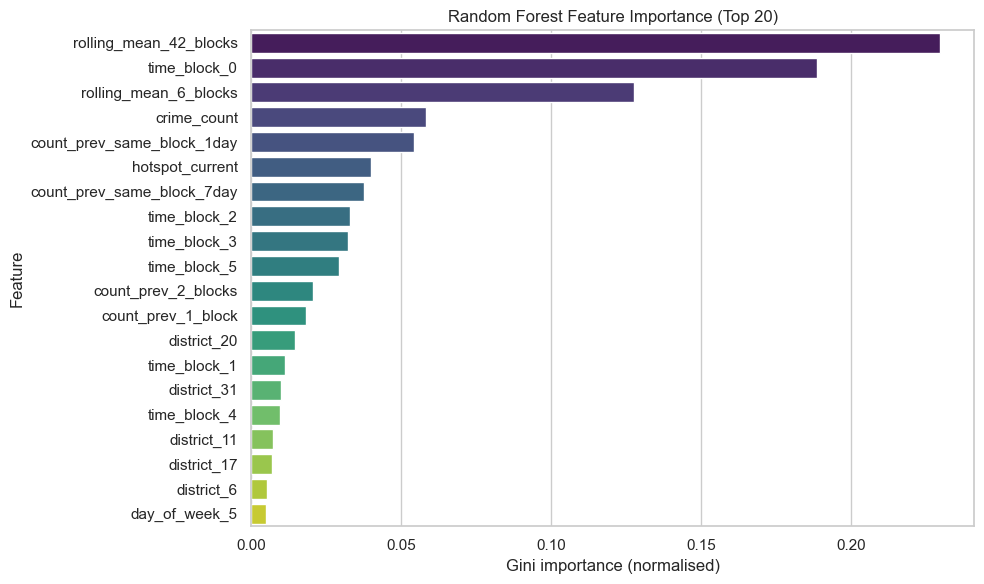

In [12]:
# Plot top-k most important individual features
TOP_K = 20
top_k_df = importance_df.head(TOP_K).copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_k_df,
    x="importance",
    y="feature",
    palette="viridis",
)
plt.title(f"Random Forest Feature Importance (Top {TOP_K})")
plt.xlabel("Gini importance (normalised)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
def assign_feature_group(feature_name: str) -> str:
    if feature_name.startswith("crime_count_current"):
        return "current_crime_level"
    if feature_name.startswith("is_hotspot_current"):
        return "current_hotspot_status"
    if "lag" in feature_name:
        return "lagged_crime_counts"
    if "rolling" in feature_name or "avg" in feature_name:
        return "rolling_averages"
    if feature_name.startswith("district_") or feature_name == "district":
        return "spatial_district"
    if feature_name.startswith("time_block_") or feature_name == "time_block":
        return "temporal_time_block"
    if feature_name.startswith("day_of_week_") or feature_name == "day_of_week":
        return "temporal_day_of_week"
    if feature_name.startswith("month_") or feature_name == "month":
        return "temporal_month"
    if feature_name.startswith("quarter_") or feature_name == "quarter":
        return "temporal_quarter"
    if feature_name.startswith("is_weekend"):
        return "temporal_weekend_indicator"
    return "other"


importance_df["group"] = importance_df["feature"].apply(assign_feature_group)
group_importance = (
    importance_df.groupby("group")["importance"].sum().sort_values(ascending=False)
)

group_importance

group
rolling_averages              0.357202
temporal_time_block           0.304128
other                         0.228664
spatial_district              0.074879
temporal_day_of_week          0.015604
temporal_weekend_indicator    0.007901
temporal_month                0.006730
temporal_quarter              0.004891
Name: importance, dtype: float64

C:\Users\12472\AppData\Local\Temp\ipykernel_46892\87784463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


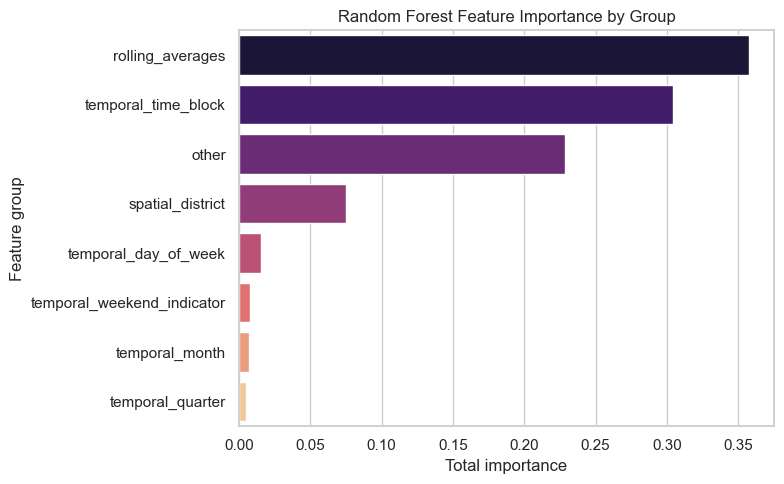

In [14]:
# Visualise aggregated importance by feature group
plt.figure(figsize=(8, 5))
sns.barplot(
    x=group_importance.values,
    y=group_importance.index,
    palette="magma",
)
plt.title("Random Forest Feature Importance by Group")
plt.xlabel("Total importance")
plt.ylabel("Feature group")
plt.tight_layout()
plt.show()

## Model Interpretation
Our feature importance analysis focuses on the Random Forest model, which was selected as the primary deployment candidate based on its strong F1-score, recall, and temporal robustness. To obtain a stable estimate of feature importance, we refit the tuned Random Forest configuration on the full 2015–2024 training panel and extracted Gini-based importance scores for the one-hot encoded feature matrix.
At the individual feature level, the model is dominated by a small number of high-impact predictors. The single most important variable is the long-term rolling average of crime (rolling_mean_42_blocks), followed by the time-of-day indicator for a specific 4-hour block (time_block_0) and the shorter-term rolling average (rolling_mean_6_blocks). These three features alone already account for roughly half of the total importance mass. Immediately after them, the model assigns non-trivial importance to the current crime count, same-block counts from the previous day and previous week, and the current hotspot status. Together, these predictors capture a mixture of long-horizon historical risk, very recent intensity, and short-cycle repetition at the same time-of-day.
Aggregating importance by feature group provides a clearer view of the model’s decision logic. Rolling-average features form the single most important group, contributing about 36% of total importance, indicating that the model relies heavily on smoothed historical crime levels to distinguish stable hotspot locations from transient noise. Time-block indicators contribute a further 30%, showing that the model systematically differentiates risk across the 4-hour temporal grid and treats some time windows as structurally higher risk than others. The remaining “other” group (about 23%) is dominated by current crime conditions, recent lags, and the current hotspot flag, which together drive sensitivity to very recent changes. Spatial district dummies contribute roughly 7–8%, while day-of-week, weekend, month, and quarter add only a small share of the overall importance, suggesting that the model treats weekly and seasonal patterns as secondary adjustments on top of the dominant “recent-history + time-of-day” signal.
This importance structure is consistent with the evaluation results. The strong weighting on recent and rolling counts explains why the Random Forest achieves high recall: once a district has accumulated sustained or repeated high activity, the model is reluctant to classify it as non-hotspot, leading to many true positives but also some false alarms. The emphasis on time-block features further explains why performance varies across months and districts: in periods or locations where the typical time-of-day pattern is disrupted (e.g., unusual spikes in lower-risk blocks), the model may struggle more, as its priors are shaped by long-run temporal averages. Finally, the relatively modest but non-negligible spatial importance suggests that Random Forest learns persistent differences between districts, but does not rely on district identity alone; instead, it combines location with temporal context and lagged counts to form its hotspot predictions.


## Business Insights
The feature importance analysis, combined with the earlier evaluation, yields several actionable insights for law enforcement planning.
First, the model’s heavy reliance on rolling historical averages indicates that persistent high-risk locations are readily identifiable. Districts that have maintained elevated rolling crime levels over many 4-hour blocks and weeks are consistently flagged as hotspots by the Random Forest. From an operational perspective, this supports long-term place-based strategies: patrol and problem-oriented policing resources can be prioritised towards districts where the rolling average features remain high, rather than reacting only to short-lived spikes.
Second, the strong importance assigned to time-block indicators, together with the importance of same-block counts from the previous day and week, points to clear time-of-day concentration of risk. Certain 4-hour blocks are systematically treated as more dangerous, and repeated activity in the same block on previous days significantly increases predicted risk for the current block. This pattern supports time-targeted deployment, where patrol intensity is scaled up during locally high-risk time windows (as defined in the feature engineering) and in the days immediately following a cluster of incidents in the same time block.
Third, the model remains sensitive to very recent conditions via the current crime count and current hotspot status. Once a district has just experienced a steep rise in incidents or has recently been classified as a hotspot, its predicted risk for the next block increases sharply, even if its long-run average is only moderate. This suggests that a dynamic updating scheme could be operationalised: patrol plans are recalibrated at the start of each 4-hour block based on the most recent counts and lagged features, allowing the agency to temporarily “surge” resources when a district’s risk profile shifts.
Fourth, while spatial district features are less important than temporal and historical features, they still carry meaningful weight. Some districts are persistently harder to predict and exhibit more volatile patterns, and the Random Forest internalises these differences by assigning higher or lower base risk to specific districts. This supports a district-specific strategy: high-importance districts—those that frequently appear among the top feature weights and show strong F1-scores in the spatial evaluation—can be earmarked for more intensive analysis, local partnerships, or targeted interventions, whereas low-importance districts may require only baseline coverage.
Finally, the relatively small importance assigned to week-of-day, weekend, month, and quarter variables implies that, within the current dataset, shorter-term and place-based dynamics matter more than coarse seasonal cycles. For practice, this suggests that the most immediate gains are likely to come from fine-grained temporal scheduling and hotspot maintenance, rather than from broad seasonal campaigns alone. However, this also identifies a limitation: the model may underweight rare but predictable seasonal events (e.g., major holidays) and any unobserved socio-economic drivers not captured in the engineered features.
Overall, the interpretation of Random Forest’s feature importance supports a policing strategy that combines long-term hotspot maintenance, time-of-day-focused patrols, and dynamic adjustment based on recent crime history. At the same time, the strong dependence on past crime patterns cautions that the model may perpetuate existing spatial and temporal biases in the data. Any operational deployment should therefore be accompanied by regular fairness checks and qualitative review by domain experts, rather than being used as a fully automated decision tool.